In [1]:
import sys
!{sys.executable} -m pip install lime shap seaborn matplotlib scikit-learn pandas numpy scikit-posthocs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Directories
PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ==========================================
# RESTORED LOGGING SETUP
# ==========================================
LOG_FILE = os.path.join(OUTPUT_DIR, "Experiment_Statistical_Results.txt")

with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS STATISTICAL RESULTS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")
# ==========================================

# Load the V2 scored datasets
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index'])
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index'])
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index'])

# Labeling: 0=Swapped, 1=Valid, 2=Shuffled
df_orig['label'] = 1
df_dist_a['label'] = 0
df_dist_b['label'] = 2

# Combine
df_combined = pd.concat([df_orig, df_dist_a, df_dist_b], ignore_index=True)

# Ensure word/token count columns exist for the features list
token_col = 'code_token_length' if 'code_token_length' in df_orig.columns else 'token_count'
for df in [df_orig, df_dist_a, df_dist_b, df_combined]:
    if 'comment_word_count' not in df.columns:
        df['comment_word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
    if 'code_token_length' not in df.columns:
        df['code_token_length'] = df[token_col]

# The specific features requested by Dr. Girma
features = ['adak_index', 'codebert_score', 'mcv', 'sfv', 'comment_word_count', 'code_token_length']

log_result("Data successfully loaded, prepared, and logging initialized.")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data successfully loaded, prepared, and logging initialized.



1. General Correlation Analysis (Spearman)
Spearman Correlation Matrix against Target Label:
                       label
label               1.000000
comment_word_count  0.001759
sfv                 0.000000
code_token_length   0.000000
codebert_score     -0.088050
adak_index         -0.376770
mcv                -0.521739


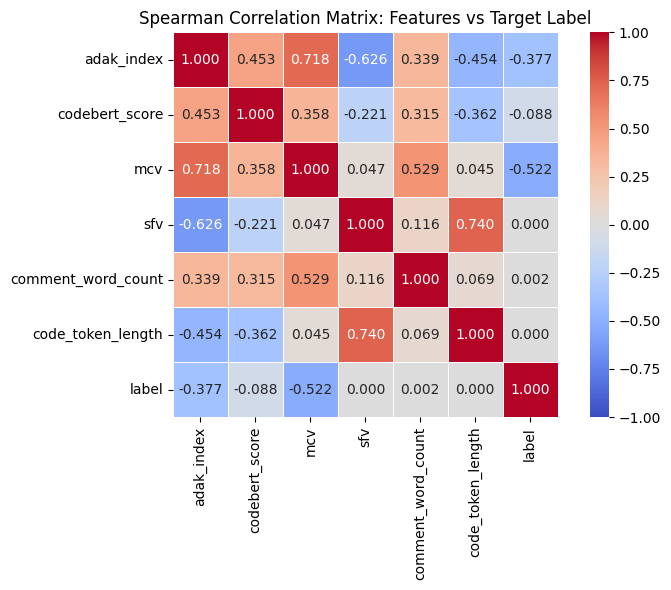

Correlation Heatmap generated and saved.


In [2]:
log_result(f"\n{'='*50}\n1. General Correlation Analysis (Spearman)\n{'='*50}")

# Calculate Spearman correlation matrix (including the target label)
corr_cols = features + ['label']
corr_matrix = df_combined[corr_cols].corr(method='spearman')

# LOG THE ACTUAL NUMBERS TO THE FILE
log_result("Spearman Correlation Matrix against Target Label:")
log_result(corr_matrix[['label']].sort_values(by='label', ascending=False).to_string())

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Spearman Correlation Matrix: Features vs Target Label')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_Correlation_Heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("Correlation Heatmap generated and saved.")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

log_result(f"\n{'='*50}\n2. Model Comparison Arena\n{'='*50}")

X = df_combined[features]
y = df_combined['label']
target_names = ['Swapped (0)', 'Valid (1)', 'Shuffled (2)']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Normalization (Required for Logistic Regression to be fair)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features)

# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
best_acc = 0
best_model_name = ""
best_model = None

# Train and evaluate all models
for name, model in models.items():
    log_result(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    log_result(f"{name} Accuracy: {acc:.4f}\n")
    
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model

log_result(f"\nWINNING MODEL: {best_model_name} with Accuracy = {best_acc:.4f}")
log_result("\nClassification Report for Best Model:")
log_result(classification_report(y_test, best_model.predict(X_test_scaled), target_names=target_names))


2. Model Comparison Arena
Training Logistic Regression...
Logistic Regression Accuracy: 0.5793

Training Decision Tree...
Decision Tree Accuracy: 0.5419

Training Random Forest...
Random Forest Accuracy: 0.5656


WINNING MODEL: Logistic Regression with Accuracy = 0.5793

Classification Report for Best Model:
              precision    recall  f1-score   support

 Swapped (0)       0.49      0.28      0.35      2400
   Valid (1)       0.53      0.52      0.52      2400
Shuffled (2)       0.65      0.94      0.77      2400

    accuracy                           0.58      7200
   macro avg       0.56      0.58      0.55      7200
weighted avg       0.56      0.58      0.55      7200



C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



3. Interpretability Analysis (SHAP & LIME) for Logistic Regression
Calculating SHAP values...


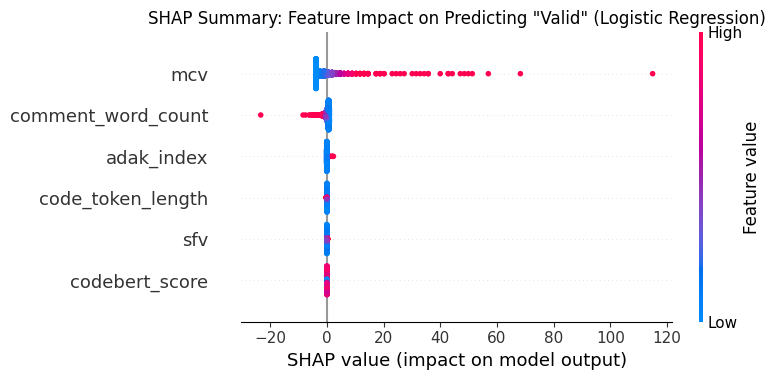

SHAP summary plot saved.

Calculating LIME (Local Interpretability)...
LIME explanation for a 'Valid' prediction saved as HTML in outputs/figures/
LIME explanation for a 'Swapped' prediction saved as HTML in outputs/figures/


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [4]:
import shap
import lime
import lime.lime_tabular

log_result(f"\n{'='*50}\n3. Interpretability Analysis (SHAP & LIME) for {best_model_name}\n{'='*50}")

# ---------------------------------------------
# 1. SHAP (Global Explanation)
# ---------------------------------------------
log_result("Calculating SHAP values...")
X_test_sample = X_test_scaled.sample(1000, random_state=42)

# Select the right SHAP explainer based on the winning model
if "Forest" in best_model_name or "Tree" in best_model_name:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sample)
else:
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_sample)

# Handle SHAP multi-class format versioning
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] # Look at impacts for predicting "Valid (Class 1)"
else:
    # Safely handle dimensions based on the model type
    if len(np.shape(shap_values)) == 2:
        shap_to_plot = shap_values
    else:
        shap_to_plot = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_test_sample, show=False)
plt.title(f'SHAP Summary: Feature Impact on Predicting "Valid" ({best_model_name})')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_SHAP_Summary_BestModel.png"), dpi=300, bbox_inches='tight')
plt.show()
log_result("SHAP summary plot saved.")

# ---------------------------------------------
# 2. LIME (Local Explanation)
# ---------------------------------------------
log_result("\nCalculating LIME (Local Interpretability)...")

# Initialize LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=features,
    class_names=target_names,
    mode='classification'
)

# Pick two specific rows from the test set to explain
valid_idx = y_test[y_test == 1].index[0]
swapped_idx = y_test[y_test == 0].index[0]

# We need their position in the scaled test array
pos_valid = np.where(X_test.index == valid_idx)[0][0]
pos_swapped = np.where(X_test.index == swapped_idx)[0][0]

# Explain the Valid instance
exp_valid = lime_explainer.explain_instance(X_test_scaled.values[pos_valid], best_model.predict_proba, num_features=4)
exp_valid.save_to_file(os.path.join(FIGURES_DIR, 'LIME_Explanation_Valid_Sample.html'))
log_result("LIME explanation for a 'Valid' prediction saved as HTML in outputs/figures/")

# Explain the Swapped instance
exp_swapped = lime_explainer.explain_instance(X_test_scaled.values[pos_swapped], best_model.predict_proba, num_features=4)
exp_swapped.save_to_file(os.path.join(FIGURES_DIR, 'LIME_Explanation_Swapped_Sample.html'))
log_result("LIME explanation for a 'Swapped' prediction saved as HTML in outputs/figures/")


Experiment 2: Paradigm Bias Analysis
Kruskal-Wallis Results:
H-Statistic: 714.0718 | p-value: 1.8650e-154

Conclusion: Significant variance exists between paradigms.
Dunn's Post-Hoc Test:
                                     Multi-Paradigm (Dynamically Typed)  \
Multi-Paradigm (Dynamically Typed)                         1.000000e+00   
Object-Oriented (Dynamically Typed)                        7.375934e-04   
Object-Oriented (Statically Typed)                         6.145277e-02   
Procedural (Statically Typed)                             8.801757e-133   

                                     Object-Oriented (Dynamically Typed)  \
Multi-Paradigm (Dynamically Typed)                          7.375934e-04   
Object-Oriented (Dynamically Typed)                         1.000000e+00   
Object-Oriented (Statically Typed)                          1.006629e-06   
Procedural (Statically Typed)                              1.866983e-118   

                                     Object-Oriented (

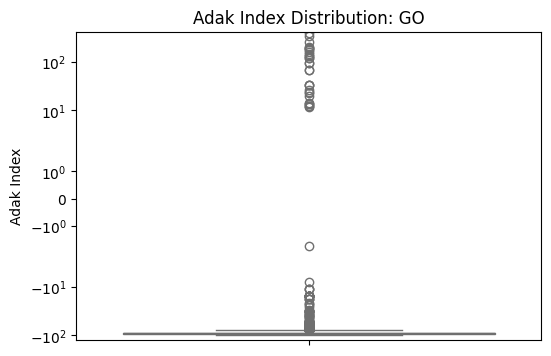

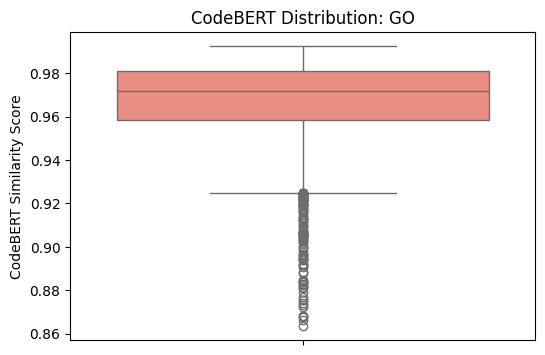

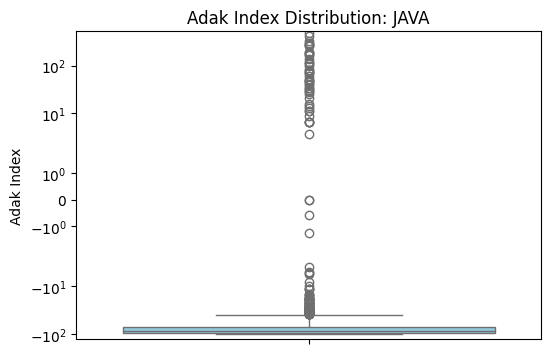

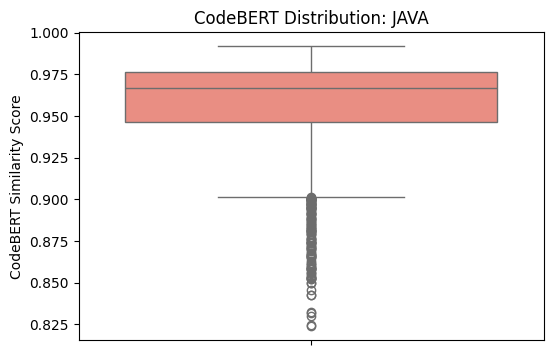

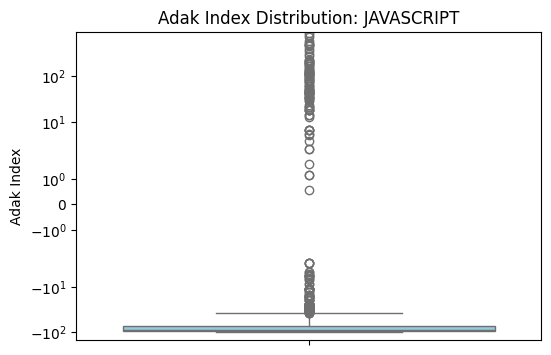

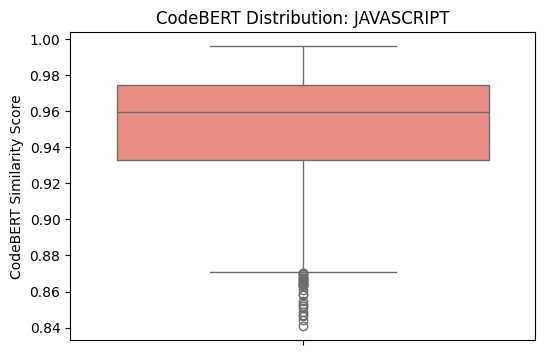

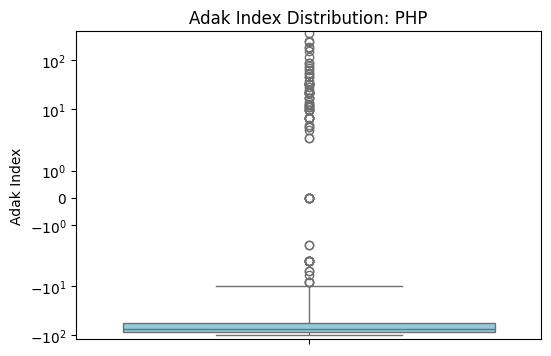

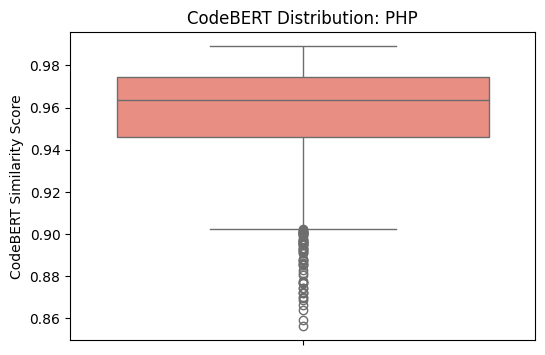

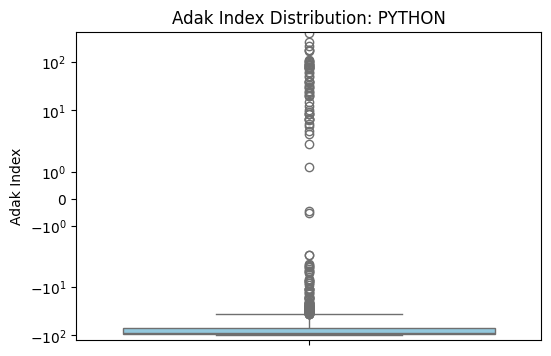

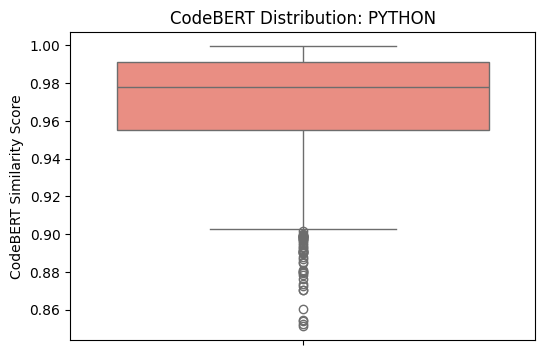

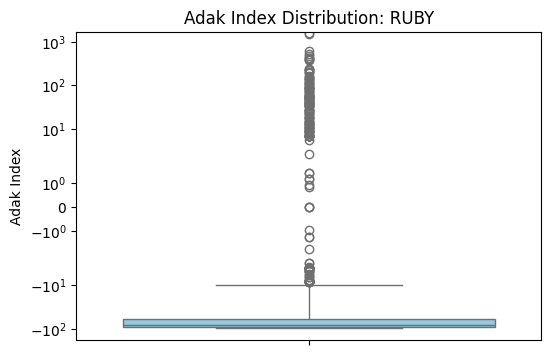

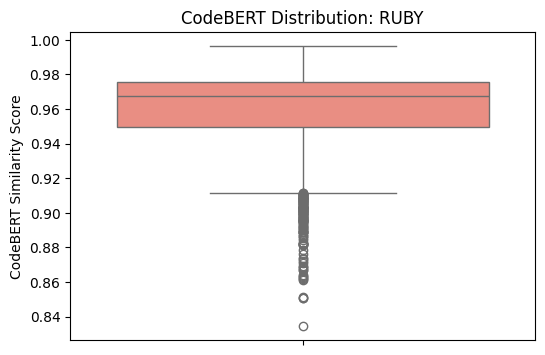

In [5]:
import scikit_posthocs as sp 

log_result(f"\n{'='*50}\nExperiment 2: Paradigm Bias Analysis\n{'='*50}")

# Updated Paradigm Map: Academically precise
paradigm_map = {
    'java': 'Object-Oriented (Statically Typed)',
    'ruby': 'Object-Oriented (Dynamically Typed)',
    'go': 'Procedural (Statically Typed)',
    'python': 'Multi-Paradigm (Dynamically Typed)',
    'javascript': 'Multi-Paradigm (Dynamically Typed)',
    'php': 'Multi-Paradigm (Dynamically Typed)'
}
df_orig['paradigm'] = df_orig['language'].str.lower().map(paradigm_map)

# 1. Kruskal-Wallis Test across paradigms
paradigms = df_orig['paradigm'].dropna().unique()
adak_groups = [df_orig[df_orig['paradigm'] == p]['adak_index'] for p in paradigms]

h_stat, p_value = stats.kruskal(*adak_groups)
log_result(f"Kruskal-Wallis Results:\nH-Statistic: {h_stat:.4f} | p-value: {p_value:.4e}\n")

if p_value < 0.05:
    log_result("Conclusion: Significant variance exists between paradigms.")
    dunn_results = sp.posthoc_dunn(df_orig, val_col='adak_index', group_col='paradigm', p_adjust='bonferroni')
    log_result("Dunn's Post-Hoc Test:\n" + str(dunn_results))

# 2. INDIVIDUAL WHISKER PLOTS (Per Language)
# Looping through each language to save individual files for the thesis
for lang in df_orig['language'].unique():
    lang_data = df_orig[df_orig['language'] == lang]
    
    # Plot Adak (Log Scale for outliers)
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=lang_data['adak_index'], color='skyblue')
    plt.yscale('symlog') 
    plt.title(f'Adak Index Distribution: {lang.upper()}')
    plt.ylabel('Adak Index')
    plt.savefig(os.path.join(FIGURES_DIR, f"Exp2_Adak_Whisker_{lang.upper()}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # Plot CodeBERT (Linear Scale)
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=lang_data['codebert_score'], color='salmon')
    plt.title(f'CodeBERT Distribution: {lang.upper()}')
    plt.ylabel('CodeBERT Similarity Score')
    plt.savefig(os.path.join(FIGURES_DIR, f"Exp2_CodeBERT_Whisker_{lang.upper()}.png"), dpi=300, bbox_inches='tight')
    plt.show()


Experiment 3: Complexity Threshold Analysis
Spearman Correlation by Complexity Segment:
Bucket: Small (SFV < 15) (n=6002) | Corr: 0.0811 (p=3.2031e-10)
Bucket: Medium (SFV 15-40) (n=4387) | Corr: 0.6613 (p=0.0000e+00)
Bucket: Large (SFV > 40) (n=1611) | Corr: 0.8332 (p=0.0000e+00)


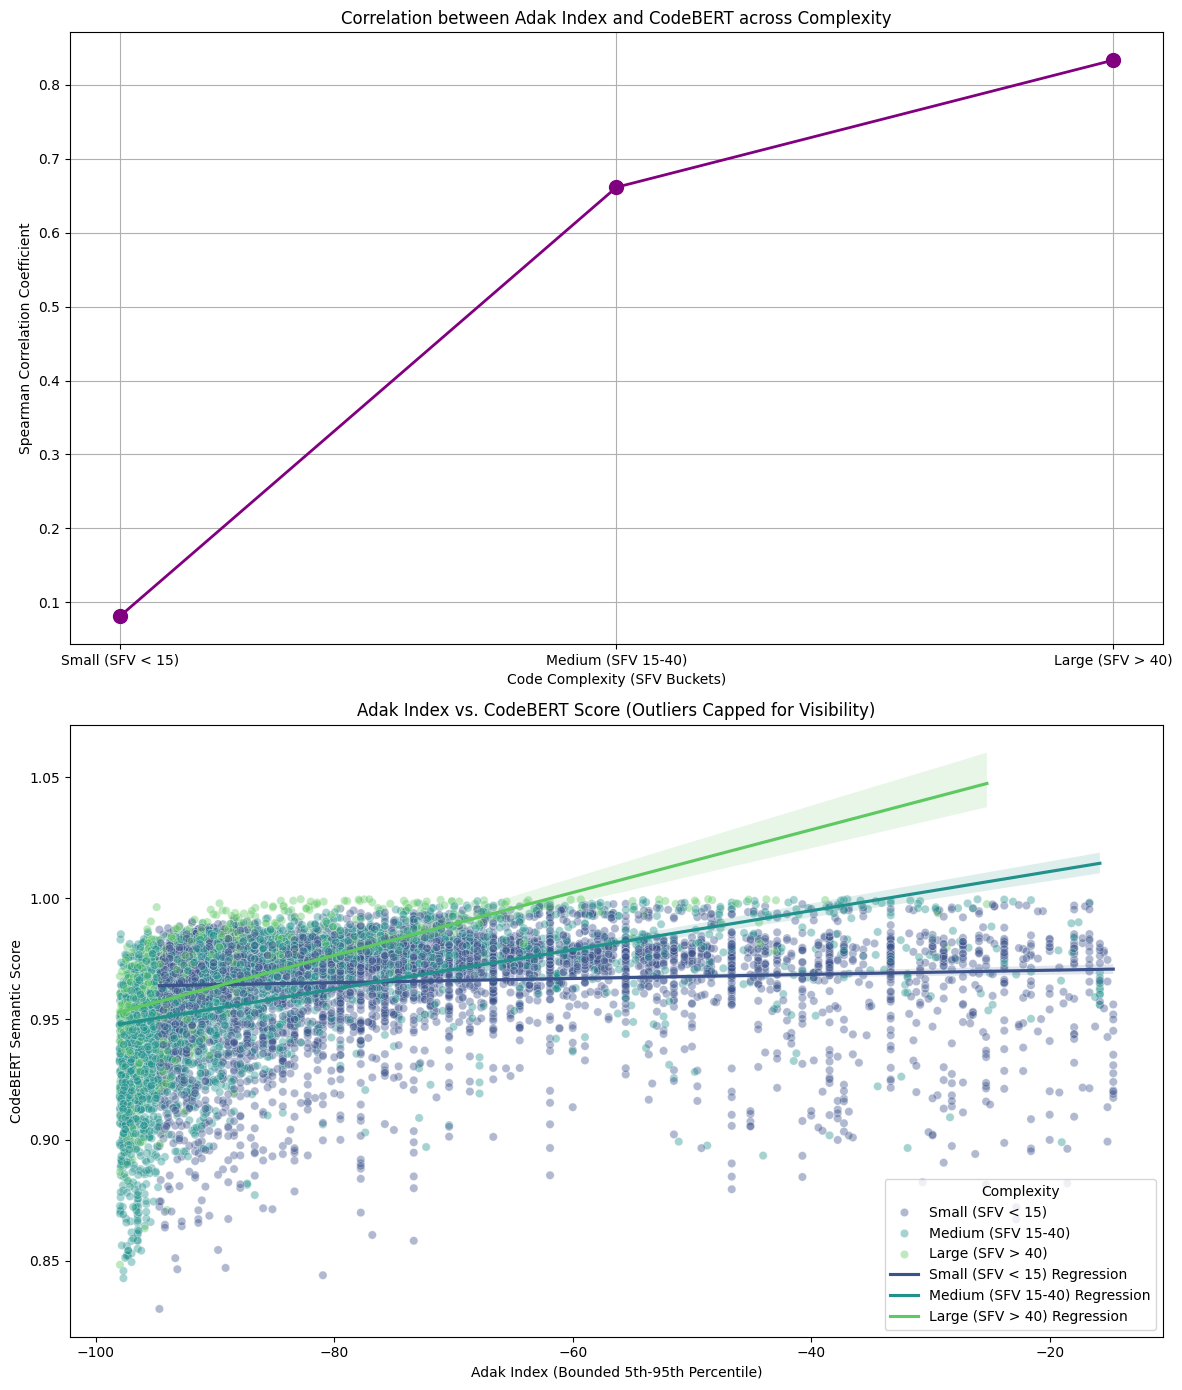

In [6]:
log_result(f"\n{'='*50}\nExperiment 3: Complexity Threshold Analysis\n{'='*50}")

bins =[0, 15, 40, np.inf]
labels =['Small (SFV < 15)', 'Medium (SFV 15-40)', 'Large (SFV > 40)']
df_orig['complexity_bucket'] = pd.cut(df_orig['sfv'], bins=bins, labels=labels)

correlations =[]
log_result("Spearman Correlation by Complexity Segment:")
for bucket in labels:
    subset = df_orig[df_orig['complexity_bucket'] == bucket]
    if len(subset) > 1:
        corr, p_val = stats.spearmanr(subset['adak_index'], subset['codebert_score'])
        correlations.append(corr)
        log_result(f"Bucket: {bucket} (n={len(subset)}) | Corr: {corr:.4f} (p={p_val:.4e})")
    else:
        correlations.append(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# 1. Degradation Curve
axes[0].plot(labels, correlations, marker='o', color='purple', linewidth=2, markersize=10)
axes[0].set_title('Correlation between Adak Index and CodeBERT across Complexity')
axes[0].set_xlabel('Code Complexity (SFV Buckets)')
axes[0].set_ylabel('Spearman Correlation Coefficient')
axes[0].grid(True)

# 2. Scatter Plots with Regression
# Cap the X-axis for visual clarity (to avoid graph crushing)
adak_lower, adak_upper = df_orig['adak_index'].quantile([0.05, 0.95])
filtered_df = df_orig[(df_orig['adak_index'] >= adak_lower) & (df_orig['adak_index'] <= adak_upper)]

sns.scatterplot(data=filtered_df, x='adak_index', y='codebert_score', hue='complexity_bucket', 
                palette='viridis', alpha=0.4, ax=axes[1])

colors = sns.color_palette('viridis', 3)
for idx, bucket in enumerate(labels):
    bucket_data = filtered_df[filtered_df['complexity_bucket'] == bucket]
    if len(bucket_data) > 1:
        sns.regplot(data=bucket_data, x='adak_index', y='codebert_score', 
                    scatter=False, ax=axes[1], line_kws={'color': colors[idx]}, label=f'{bucket} Regression')

axes[1].set_title('Adak Index vs. CodeBERT Score (Outliers Capped for Visibility)')
axes[1].set_xlabel('Adak Index (Bounded 5th-95th Percentile)')
axes[1].set_ylabel('CodeBERT Semantic Score')
axes[1].legend(title='Complexity', loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp3_Complexity_Threshold_All.png"), dpi=300, bbox_inches='tight')
plt.show()